[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tviskaron/SB-RL-2026/blob/main/seminars/05-seminar-reinforce-actor-critic.ipynb)

# Градиент стратегии: REINFORCE и Actor-Critic.

В некоторых задачах для нахождения удовлетворительной стратегии необязательно в точности знать структуру всей среды. Например, в задаче поднятия кубика робототехнической рукой вместо точной аппроксимации полезности $Q(s,a)$ достаточно знать, что выгоднее: двигаться вправо, если кубик справа, и влево в ином случае. С этим же наблюдением связано и предположение, что задача поиска удовлетворительной стратегии проще, нежели задача точной оценки функции полезности.

В данном семинаре познакомимся с простейшим методом прямой оптимизации стратегии REINFORCE, в котором параметры, задающие вероятностную стратегию, изменяются в соответствии с градиентом математического ожидания отдач: 

$$J(\theta)= \mathbb{E}[G(\tau)],$$

$$\theta \leftarrow \theta +\alpha \nabla_{\theta} J(\theta),$$

В первом выражении математическое ожидание берется по распределениям начальных состояний, вероятностным функциям переходов и вознаграждений среды, а также по вероятностной стратегии агента $\pi_\theta$. Благодаря теореме о существовании стационарного распределения марковской цепи, это выражение может быть переписано через стационарное распределение $d^\pi$ посещения состояний в среде:

$$J(\theta)= \mathbb{E}_{s \sim d^\pi}[V^{\pi}(s)] = \mathbb{E}_{s \sim d^\pi, a \sim \pi(s)} [Q^{\pi}(s, a)] =: \mathbb{E}_\pi [Q^{\pi}(s, a)].$$

Метод REINFORCE также использует теорему о градиенте стратегии, на основе которой построено целое семейство алгоритмов прямой оптимизации стратегии и актор-критиков. Теорема о градиенте стратегии связывает градиент целевой функции $J$ и градиент самой стратегии:

$$\nabla_\theta J(\theta) = \mathbb{E}_\pi [Q^\pi(s, a) \nabla_\theta \ln \pi_\theta(a \vert s)]$$

Для оценки полезности действий $Q^\pi(s, a)$ REINFORCE использует несмещенную Монте-Карло оценку на основе полученных в среде отдач $G_t$ (за некоторое фиксированное число эпизодов в среде). С учетом этого обновление весов осуществляется по правилу:

$$\nabla_\theta J(\theta) = \mathbb{E}_\pi [G_t \nabla_\theta \ln \pi_\theta(a_t \vert s_t)]$$

Более подробное (но все равно короткое) описание градиента стратегии, и в частности REINFORCE, можно посмотреть в [блоге Lilian Weng из OpenAI](https://lilianweng.github.io/posts/2018-04-08-policy-gradient/#policy-gradient), либо полноценно разобраться в соответствующей секции классического учебника Саттона и Барто.

По аналогии с DQN реализуем алгоритм REINFORCE для решения среды [CartPole](https://gymnasium.farama.org/environments/classic_control/cart_pole/), цель которой балансировать палочкой в вертикальном положении, управляя только тележкой, к которой она прикреплена.

![cartpole](https://gymnasium.farama.org/_images/cart_pole.gif)

![cartpole](https://www.researchgate.net/publication/362568623/figure/fig5/AS:1187029731807278@1660021350587/Screen-capture-of-the-OpenAI-Gym-CartPole-problem-with-annotations-showing-the-cart.png)

In [1]:
try:
    import gymnasium
except ImportError:
    %pip install -q "gymnasium[classic-control]>=1.0,<2.0"

In [2]:
from collections import deque

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

import torch
import torch.nn as nn
from torch.distributions import Categorical

%matplotlib inline

In [3]:
env = gym.make("CartPole-v1")
env.reset()

print(f'{env.observation_space=}')
print(f'{env.action_space=}')

n_actions = env.action_space.n
state_dim = env.observation_space.shape
print(f'Action_space: {n_actions} | State_space: {env.observation_space.shape}')

env.observation_space=Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
env.action_space=Discrete(2)
Action_space: 2 | State_space: (4,)


Вспомогательные методы:

In [4]:
def to_tensor(x, dtype=np.float32):
    if isinstance(x, torch.Tensor):
        return x
    x = np.asarray(x, dtype=dtype)
    x = torch.from_numpy(x)
    return x

Сначала зададим структуру для хранения траекторий полных эпизодов для Монте-Карло оценки отдачи.

In [5]:
class Rollouts:
    # Класс Rollouts хранит траектории взаимодействия агента со средой. 

    def __init__(self):
        self.logprobs = []    # Логарифмы вероятностей выбранных действий
        self.rewards = []     # Полученные награды
        self.terminateds = [] # Флаги окончания эпизодов
        
    def append(self, log_prob, reward, terminated):
        """
        Добавляет в хранилище логарифм вероятности выбранного действия, 
        вознаграждение и флаг терминальности состояни.
        """
        self.logprobs.append(log_prob)
        self.rewards.append(reward)
        self.terminateds.append(terminated)
    
    def get_data(self, gamma):
        """
        Возвращает вектор логарифмов вероятностей совершенных 
        действий и вектор отдач.
        """
        # Подготовь данные накопленных траекторий для обучения:
        # Преобразуй вознаграждения в отдачи для этих состояний
        # Подсказки:
        #    1) обход списков удобнее сделать в обратном порядке, 
        #    2) не забудь сбрасывать отдачу при окончании эпизода
        #    3) при обратном порядке построения результата 
        #       не забудь развернуть его обратно

        """Комментарий:
        Этот метод преобразует последовательность наград в отдачи (returns). 
        Для каждого момента времени t отдача вычисляется как:
        G_t = r_t + g*r_{t+1} + g^2*r_{t+2} + ...
        В итоге метод возвращает:
        - Тензор логарифмов вероятностей действий
        - Тензор соответствующих им отдач
        Эти данные затем используются для обновления параметров стратегии по формуле градиента стратегии, минимизируя loss = -mean(returns logprobs)
        """

        """<codehere>"""
        rollout_len = len(self.rewards)
        returns = np.empty(rollout_len, dtype=float)
        ret = 0.0
        for i in reversed(range(rollout_len)):
            reward, terminated = self.rewards[i], self.terminateds[i]
            returns[i] = ret = reward + gamma * ret * (not terminated)
        """</codehere>"""
        
        return torch.stack(self.logprobs), to_tensor(returns)
    
    def __len__(self):
        return len(self.logprobs)
    
    def clear(self):
        self.logprobs.clear()
        self.rewards.clear()
        self.terminateds.clear()

Далее зададим отдельно класс с нейросетевой моделью агента `ActorModel` и класс самого агента, объекты которого будут содержать в себе нейросетевую модель, её оптимизатор и хранилище Монте-Карло траекторий. В конце зададим функцию обучения полученного агента.

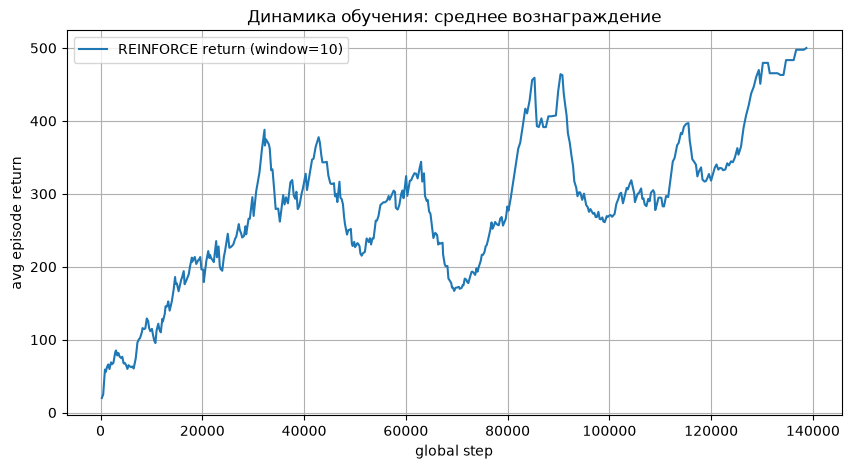

global_step=138713 | avg_return=500.000
Решено!


In [11]:
class ActorModel(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()

        # Инициализируйте сеть агента с одной головой 
        # softmax-актором: `net` и `actor_head`
        # NB: сразу разделим на тело и голову, тк в будущем на базе 
        # этой архитектуры будем делать уже актор-критика 
        # c телом и двумя головами
        """<codehere>"""
        from_dim = input_dim
        layers = []
        for to_dim in hidden_dims:
            layers.extend([
                nn.Linear(from_dim, to_dim),
                nn.ReLU()
            ])
            from_dim = to_dim
        
        self.net = nn.Sequential(*layers)
        self.actor_head = nn.Sequential(
            nn.Linear(hidden_dims[-1], output_dim),
            nn.Softmax(dim=-1)
        )
        """</codehere>"""
        
    def forward(self, state):
        # Вычислите выбранное действие и логарифм вероятности его выбора:
        # Для этого вам пригодится `Categorical` из torch.distributions — 
        #   у него есть методы sample и log_prob.

        """Комментарий:
            Пропускает состояние через сеть
            Получает вероятности действий
            Создает категориальное распределение
            Выбирает случайное действие согласно распределению
            Вычисляет логарифм вероятности выбранного действия
            Возвращает выбранное действие и его логарифм вероятности
        """

        """<codehere>"""
        state = self.net(state) # 4 -> 128
        
        action_probs = self.actor_head(state) # 128 -> 2 ~[0,1]

        dist = Categorical(action_probs)
        # Создаем категориальное распределение на основе вероятностей
        # Это объект, который позволяет:
        # - случайно выбирать действия с заданными вероятностями
        # - вычислять логарифм вероятности выбранного действия
        # dist теперь представляет распределение с P(action=0) = 0.7, P(action=1) = 0.3

        action = dist.sample()
        # Случайно выбираем действие согласно распределению
        # С вероятностью 0.7 получим action=0 (влево)
        # С вероятностью 0.3 получим action=1 (вправо)
        # Допустим, в этот раз выпало: action = tensor(0)  # движение влево

        log_prob = dist.log_prob(action)
        # Вычисляем натуральный логарифм вероятности выбранного действия
        # Если выбрали action=0 (вероятность 0.7):
        # log_prob = ln(0.7) = -0.357
        # Если выбрали action=1 (вероятность 0.3):
        # log_prob = ln(0.3) = -1.204
        # Этот логарифм нужен для вычисления градиента при обучении

        action = action.item()
        """</codehere>"""
        
        return action, log_prob # получили стохастическую стратегию!


class ReinforceAgent:
    def __init__(self, state_dim, action_dim, hidden_dims, lr, gamma):
        self.lr = lr
        self.gamma = gamma

        # Инициализируйте модель агента и ее SGD оптимизатор
        #   (например, `torch.optim.Adam`)
        """<codehere>"""
        self.actor = ActorModel(state_dim, hidden_dims, action_dim)
        self.opt = torch.optim.Adam(self.actor.parameters(), lr=lr)
        """</codehere>"""

        self.rollouts = Rollouts()
        
    def act(self, state):
        # Произведите выбор действия
        """<codehere>"""
        action, logprob = self.actor(to_tensor(state))
        """</codehere>"""
        return action, logprob
        
    def append_to_rollouts(self, logprob, r, done):
        # Добавьте новый экземпляр данных в память роллаутов.
        """<codehere>"""
        self.rollouts.append(logprob, r, done)
        """</codehere>"""
    
    def update(self, min_data_size=1):
        if len(self.rollouts) < min_data_size:
            # Пропускаем шаг обновления, если собрали мало данных
            return
        
        self.update_actor()

        # Очищаем накопленные роллауты после шага обучения
        self.rollouts.clear()

    def update_actor(self):
        logprobs, returns = self.rollouts.get_data(self.gamma)

        # Реализуйте шаг обновления актора: вычислите ошибку `loss` 
        # и произведите шаг обновления градиентным спуском. 
        """<codehere>"""
        # Считаем ошибку
        loss = -torch.mean(returns * logprobs)
        
        self.opt.zero_grad()
        loss.backward()
        self.opt.step()
        """</codehere>"""


def run_reinforce_actor(
    env_name="CartPole-v1", 
    hidden_dims=(128, 128), lr=1e-3, gamma=0.99,
    total_max_steps=200_000,
    # данные скольких эпизодов используются для одного шага обновления
    train_schedule_episodes=4, min_data_size=64,
    eval_schedule=1000, smooth_ret_window=10, success_ret=500.
):
    env = gym.make(env_name)
    episode_return_history = deque(maxlen=smooth_ret_window)
    all_returns = []
    all_steps = []
    fig, ax = plt.subplots(figsize=(10, 5))

    agent = ReinforceAgent(
        state_dim=env.observation_space.shape[0], action_dim=env.action_space.n, 
        hidden_dims=hidden_dims, lr=lr, gamma=gamma
    )
    
    s, _ = env.reset()
    done, episode_return = False, 0.
    i_episode = 0
    eval = False

    for global_step in range(1, total_max_steps+1):
        # Получаем действие и его логарифм вероятности
        a, logprob = agent.act(s)
        # Выполняем действие
        s_next, r, terminated, truncated, _ = env.step(a)
        episode_return += r
        done = terminated or truncated

        # Сохраняем опыт
        agent.append_to_rollouts(logprob, r, done)

        # evaluate
        if global_step % eval_schedule == 0:
            eval = True

        s = s_next
        if done:
            i_episode += 1
            # обучение по расписанию (на число эпизодов)
            if i_episode % train_schedule_episodes == 0:
                agent.update(min_data_size)

            if eval:
                # для этого алгоритма не будем делать шаг оценки 
                # (но можно было бы, например, использовать жадную стратегию),
                # поэтому вместо этого сохраним результаты последнего 
                # тренировочного эпизода
                episode_return_history.append(episode_return)
                avg_return = np.mean(episode_return_history)
                all_returns.append(avg_return)
                all_steps.append(global_step)
                clear_output(wait=True)
                ax.clear()
                ax.plot(all_steps, all_returns, label=f'REINFORCE return (window={smooth_ret_window})')
                ax.set_xlabel('global step')
                ax.set_ylabel('avg episode return')
                ax.set_title('Динамика обучения: среднее вознаграждение')
                ax.grid(True)
                ax.legend()
                display(fig)
                print(f'{global_step=} | {avg_return=:.3f}')
                if avg_return >= success_ret:
                    print('Решено!')
                    break

            s, _ = env.reset()
            done, episode_return = False, 0.
            eval = False
    plt.close(fig)

run_reinforce_actor(eval_schedule=250)

# Actor-Critic

Теорема о градиенте стратегии связывает градиент целевой функции  и градиент самой стратегии:

$$\nabla_\theta J(\theta) = \mathbb{E}_\pi [Q^\pi(s, a) \nabla_\theta \ln \pi_\theta(a \vert s)]$$

Встает вопрос, как оценить $Q^\pi(s, a)$? В чистом policy-based алгоритме REINFORCE используется отдача $G_t$, полученная методом Монте-Карло в качестве несмещенной оценки $Q^\pi(s, a)$. В Actor-Critic же предлагается отдельно обучать нейронную сеть Q-функции — критика.

Актор-критиком часто называют обобщенный фреймворк (подход), нежели какой-то конкретный алгоритм. Как подход актор-критик не указывает, каким конкретно [policy gradient] методом обучается актор и каким [value based] методом обучается критик. Таким образом актор-критик задает целое [семейство](https://proceedings.neurips.cc/paper_files/paper/1999/file/6449f44a102fde848669bdd9eb6b76fa-Paper.pdf) различных алгоритмов. Рекомендую в качестве шпаргалки использовать упомянутый в тетрадке с REINFORCE [пост из блога Lilian Weng](https://lilianweng.github.io/posts/2018-04-08-policy-gradient/), посвященный наиболее популярным алгоритмам семейства актор-критиков

В данной тетрадке познакомимся с наиболее простым вариантом актор-критика, который так и называют Actor-Critic:

$$\nabla_\theta J(\theta) = \mathbb{E}_\pi [Q^\pi(s, a) \nabla_\theta \ln \pi_\theta(a|s)]$$

In [21]:
# # Example:
# # Вариант с общим телом
# self.net = nn.Sequential(*create_body())  # Общие слои
# self.actor_head = nn.Sequential(...)      # Специфичные слои для актора
# self.critic_head = nn.Sequential(...)     # Специфичные слои для критика

# # При прямом проходе:
# state = self.net(state)                # Сначала через общее тело
# action_probs = self.actor_head(state)  # Затем через голову актора
# q_values = self.critic_head(state)     # Или через голову критика

# # [+] Меньше параметров (экономия памяти)
# # [+] Может быть полезно, если признаки, извлекаемые из состояния, полезны для обеих задач
# # [-] Может возникать конфликт градиентов при обучении
# # [-] Менее гибкая архитектура


# # Вариант без общего тела
# self.net = None
# self.actor_head = nn.Sequential(
#     *create_body(),  # Полная сеть актора
#     nn.Linear(hidden_dims[-1], output_dim),
#     nn.Softmax(dim=-1),
# )
# self.critic_head = nn.Sequential(
#     *create_body(),  # Полная сеть критика
#     nn.Linear(hidden_dims[-1], output_dim),
# )

# # [+] Нет конфликта градиентов
# # [+] Каждая сеть может специализироваться на своей задаче
# # [+] Более стабильное обучение
# # [-] Больше параметров
# # [-] Требует больше вычислений

In [22]:
def to_tensor(x, dtype=np.float32):
    if isinstance(x, torch.Tensor):
        return x
    x = np.asarray(x, dtype=dtype)
    x = torch.from_numpy(x)
    return x

# symlog и symexp - пара взаимообратных функций для нелинейного масштабирования значений:
def symlog(x):
    """Compute symlog values for a vector `x`. It's an inverse operation for symexp."""
    return torch.sign(x) * torch.log(torch.abs(x) + 1)

def symexp(x):
    """Compute symexp values for a vector `x`. It's an inverse operation for symlog."""
    return torch.sign(x) * (torch.exp(torch.abs(x)) - 1.0)

# Пример:
# x = torch.tensor([-100, -1, 0, 1, 100])
# log_x = symlog(x)  # tensor([-4.6151, -0.6931,  0.0000,  0.6931,  4.6151])
# exp_x = symexp(log_x)  # вернет примерно исходный x


# SymExpModule - обертка для использования symexp в нейронных сетях:
class SymExpModule(nn.Module):
    def forward(self, x):
        return symexp(x)

# Пример:
# layer = nn.Sequential(
#     nn.Linear(10, 1),
#     SymExpModule()  # Применяет symexp к выходу линейного слоя
# )


# ======== Код ниже взят из тетрадки по DQN =======    
def select_action_eps_greedy(Q, state, epsilon):
    """Выбирает действие epsilon-жадно."""
    # Преобразуем состояние в тензор
    if not isinstance(state, torch.Tensor):
        state = torch.tensor(state, dtype=torch.float32)

    # Получаем Q-значения для всех действий в данном состоянии
    Q_s = Q(state).detach().numpy()
    
    # С вероятностью epsilon выбираем случайное действие
    # action = 
    """<codehere>"""
    if np.random.random() < epsilon:
        n_actions = Q_s.shape[-1]
        action = np.random.choice(n_actions)
    # Иначе выбираем действие с максимальным Q-значением
    else:
        action = np.argmax(Q_s)
    """</codehere>"""
    
    action = int(action)
    return action

def get_batch(replay_buffer):
    # split an array of samples into arrays: states, actions, rewards, next_actions, terminateds
    """<codehere>"""
    states, actions, rewards, next_states, terminateds = [], [], [], [], []
    for s, a, r, n_s, done in replay_buffer:
        states.append(s)
        actions.append(a)
        rewards.append(r)
        next_states.append(n_s)
        terminateds.append(done)
    """</codehere>"""
        
    return np.array(states), np.array(actions), np.array(rewards), np.array(next_states), np.array(terminateds)
    # return map(np.array, [states, actions, rewards, next_states, terminateds])

def sample_batch(replay_buffer, n_samples):
    # sample randomly `n_samples` samples from replay buffer
    # and split an array of samples into arrays: states, actions, rewards, next_states, terminateds
    """<codehere>"""
    # Ограничиваем размер выборки размером буфера
    n_samples = min(len(replay_buffer), n_samples)

    # Случайно выбираем индексы
    indices = np.random.choice(len(replay_buffer), n_samples, replace=False)

    # Собираем данные по выбранным индексам
    states, actions, rewards, next_states, terminateds = [], [], [], [], []
    for i in indices:
        s, a, r, n_s, done = replay_buffer[i]
        states.append(s)
        actions.append(a)
        rewards.append(r)
        next_states.append(n_s)
        terminateds.append(done)
    """</codehere>"""
        
    return np.array(states), np.array(actions), np.array(rewards), np.array(next_states), np.array(terminateds)

## Shared-body Actor-Critic

Актор и критик могут обучаться в разных режимах — актор только on-policy (шаг обучения на текущей собранной подтраектории), а критик on-policy или off-policy (шаг обучения на текущей подтраектории или на батче из replay buffer). Это с одной стороны привносит гибкость в обучение, с другой — усложняет его.

Если актор и критик оба обучаются on-policy, то имеет смысл объединить их сетки в одну и делать общий шаг обратного распространения ошибки. Однако, если они обучаются в разных режимах (и с разной частотой обновления), то велика вероятность, что их шаги обучения могут начать конфликтовать в случае общего тела — для такого варианта намного предпочтительнее разделить их на разные подсети (либо аккуратно настраивать гиперпарметры, чтобы стабилизировать обучение). В целом, рекомендуется использовать общий энкодер наблюдений, а далее как можно скорее разделять головы.

Далее сначала попробуем реализацию актор-критика с общим телом и с on-policy вариантом обучения.

$$\nabla_\theta J(\theta) = \mathbb{E}_\pi [Q^\pi(s, a) \nabla\theta \ln \pi_\theta(a|s)]$$

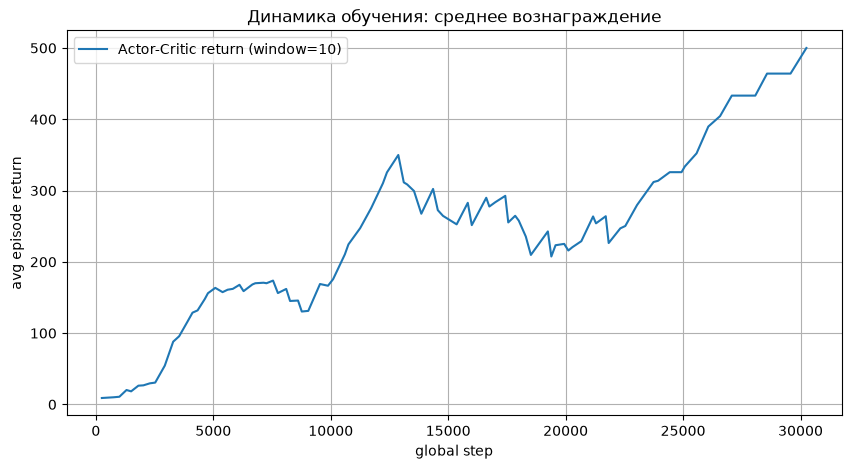

global_step=30249 | avg_return=500.000
Решено!


In [28]:
class ActorBatch:
    def __init__(self):
        self.logprobs = []
        self.q_values = []
        
    def append(self, log_prob, q_value):
        self.logprobs.append(log_prob)
        self.q_values.append(q_value)
    
    def clear(self):
        self.logprobs.clear()
        self.q_values.clear()

    
class ActorCriticModel(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()

        # Инициализируйте сеть агента с двумя головами: softmax-актора и линейного критика
        # self.net, self.actor_head, self.critic_head =
        """<codehere>"""
        def create_body():
            from_dim = input_dim
            layers = []
            for to_dim in hidden_dims:
                layers.extend([
                    nn.Linear(from_dim, to_dim),
                    nn.Tanh()
                ])
                from_dim = to_dim
            return layers
        
        self.net = nn.Sequential(*create_body())

        self.actor_head = nn.Sequential(
            nn.Linear(hidden_dims[-1], output_dim),
            nn.Softmax(dim=-1)
        )

        self.critic_head = nn.Sequential(
            nn.Linear(hidden_dims[-1], output_dim),

        )

        """</codehere>"""
        
    def forward(self, state):
        # Вычислите выбранное действие, логарифм вероятности его выбора и соответствующее значение Q-функции
        # Опционально, здесь можно вместо Q[s, a] возвращать A[s, a] — тогда это будет аналог Advantage Actor-Critic (A2C)
        """<codehere>"""
        # Обработка входного состояния через общую сеть
        state = self.net(state)

        # Получаем вероятности действий через голову актора
        action_probs = self.actor_head(state)

        # Создаем категориальное распределение на основе вероятностей
        dist = Categorical(action_probs)

        # Выбираем случайное действие согласно распределению
        action = dist.sample()
        
        # Вычисляем логарифм вероятности выбранного действия
        log_prob = dist.log_prob(action)

        # Преобразуем tensor в число Python
        action = action.item()
        
        # Блок вычисления Q-значений и преимущества (advantage)
        with torch.no_grad():
            # Получаем Q-значения для всех действий
            Q_s = self.critic_head(state)
            # Например: Q_s = [1.5, 0.8]
            # 1.5 - ожидаемая награда для действия влево
            # 0.8 - ожидаемая награда для действия вправо

            Q_s_a = Q_s[action]
            
            # Вычисляем максимальное Q-значение (оценка ценности состояния V)
            V_s, _ = torch.max(Q_s, axis=-1)
            # V_s = 1.5 (максимум из [1.5, 0.8])

            # Вычисляем преимущество: насколько выбранное действие лучше среднего
            advantage = Q_s_a - V_s
            # advantage = 1.5 - 1.5 = 0 (если выбрали лучшее действие)
            # advantage = 0.8 - 1.5 = -0.7 (если выбрали худшее действие)
            
            # Используем преимущество вместо Q-значения
            Q_s_a = advantage
        """</codehere>"""
        
        return action, log_prob, Q_s_a
    
    def evaluate(self, state):
        # Вычислите значения Q-функции для данного состояния
        """<codehere>"""
        state = self.net(state)

        q_values = self.critic_head(state)

        """</codehere>"""
        return q_values


class ActorCriticAgent:
    def __init__(self, state_dim, action_dim, hidden_dims, lr, gamma, critic_rb_size):
        self.lr = lr
        self.gamma = gamma

        # Инициализируйте модель актор-критика и SGD оптимизатор (например, `torch.optim.Adam)`)
        """<codehere>"""
        self.actor_critic = ActorCriticModel(state_dim, hidden_dims, action_dim)
        self.opt = torch.optim.Adam(self.actor_critic.parameters(), lr=lr)
        """</codehere>"""

        self.actor_batch = ActorBatch()
        self.critic_rb = deque(maxlen=critic_rb_size)
        
    def act(self, state):
        # Произведите выбор действия и сохраните необходимые данные в батч для последующего обучения
        # Не забудьте сделать q_value.detach()
        # self.actor_batch.append(..)
        """<codehere>"""
        state = to_tensor(state)
        action, logprob, q_value = self.actor_critic(state)

        self.actor_batch.append(logprob, q_value.detach())

        # NB: Для дебага, можно сначала обучать только критика и убедиться, что DQN работает
        # action = select_action_eps_greedy(self.actor_critic.critic_head, state, 0.05)
        """</codehere>"""
        
        return action
        
    def append_to_replay_buffer(self, s, a, r, next_s, terminated):
        # Добавьте новый экземпляр данных в память прецедентов.
        """<codehere>"""
        self.critic_rb.append((s, a, r, next_s, terminated))
        """</codehere>"""
    
    def evaluate(self, state):
        return self.actor_critic.evaluate(state)
    
    def update(self, rollout_size):
        if len(self.actor_batch.q_values) < rollout_size:
            return

        self.opt.zero_grad()
        loss = self.update_critic()
        loss += self.update_actor()
        loss.backward()

        self.opt.step()
        self.actor_batch.clear()
        # self.critic_rb.clear()

    def update_actor(self):
        Q_s_a = to_tensor(self.actor_batch.q_values)
        logprobs = torch.stack(self.actor_batch.logprobs)

        # Реализуйте шаг обновления актора — вычислите ошибку `loss` и произведите шаг обновления градиентным спуском. 
        """<codehere>"""
        # Считаем ошибку
        loss = -torch.mean(Q_s_a * logprobs)
        
        """</codehere>"""
        return loss
    
    def update_critic(self):
        # Реализуйте n_updates шагов обучения критика.
        """<codehere>"""
        train_batch = get_batch(self.critic_rb)
        states, actions, rewards, next_states, terminateds = train_batch

        loss = self.compute_td_loss(states, actions, rewards, next_states, terminateds)

        """</codehere>"""
        return loss
        
    def compute_td_loss(
        self, states, actions, rewards, next_states, terminateds, regularizer=0.1
    ):
        # переводим входные данные в тензоры
        s = to_tensor(states)                     # shape: [batch_size, state_size]
        a = to_tensor(actions, int).long()        # shape: [batch_size]
        r = to_tensor(rewards)                    # shape: [batch_size]
        s_next = to_tensor(next_states)           # shape: [batch_size, state_size]
        term = to_tensor(terminateds, bool)       # shape: [batch_size]

        
        # получаем Q[s, a] для выбранных действий в текущих состояниях (для каждого примера из батча)
        # Q_s_a = ...
        """<codehere>"""
        Q_s_a = torch.gather(
            self.evaluate(s), dim=1, index=torch.unsqueeze(a, 1)
        ).squeeze(1)
        """</codehere>"""
    
        # получаем Q[s_next, *] — значения полезности всех действий в следующих состояниях
        # Q_sn = ...,
        # а затем вычисляем V*[s_next] — оптимальные значения полезности следующих состояний
        # V_sn = ...
        """<codehere>"""
        with torch.no_grad():
            Q_sn = self.evaluate(s_next)
            V_sn, _ = torch.max(Q_sn, axis=-1)

        """</codehere>"""
    
        # вычисляем TD target и далее TD error
        # target = ...
        # td_error = ...
        """<codehere>"""
        target = r + self.gamma * V_sn * torch.logical_not(term)
        td_error = target - Q_s_a
        """</codehere>"""
    
        # MSE loss для минимизации
        loss = torch.mean(td_error ** 2)
        # добавляем регуляризацию на значения Q 
        loss += regularizer * Q_s_a.mean()
        return loss

def run_actor_critic(
        env_name="CartPole-v1", 
        hidden_dims=(128, 128), lr=1e-3,
        total_max_steps=200_000,
        train_schedule=8, replay_buffer_size=500,
        eval_schedule=1000, smooth_ret_window=10, success_ret=500.
):
    env = gym.make(env_name)
    episode_return_history = deque(maxlen=smooth_ret_window)
    all_steps = []
    all_returns = []
    fig, ax = plt.subplots(figsize=(10, 5))

    agent = ActorCriticAgent(
        state_dim=env.observation_space.shape[0], 
        action_dim=env.action_space.n, hidden_dims=hidden_dims,
        lr=lr, gamma=.995, critic_rb_size=replay_buffer_size
    )
    
    s, _ = env.reset()
    done, episode_return = False, 0.
    eval = False

    for global_step in range(1, total_max_steps+1):
        a = agent.act(s)
        s_next, r, terminated, truncated, _ = env.step(a)
        episode_return += r
        done = terminated or truncated

        # train step
        agent.append_to_replay_buffer(s, a, r, s_next, terminated)
        agent.update(train_schedule)

        # evaluate
        if global_step % eval_schedule == 0:
            eval = True

        s = s_next
        if done:
            if eval:
                episode_return_history.append(episode_return)
                avg_return = np.mean(episode_return_history)
                all_steps.append(global_step)
                all_returns.append(avg_return)
                clear_output(wait=True)
                ax.clear()
                ax.plot(all_steps, all_returns, label=f'Actor-Critic return (window={smooth_ret_window})')
                ax.set_xlabel('global step')
                ax.set_ylabel('avg episode return')
                ax.set_title('Динамика обучения: среднее вознаграждение')
                ax.grid(True)
                ax.legend()
                display(fig)
                print(f'{global_step=} | {avg_return=:.3f}')
                if avg_return >= success_ret:
                    print('Решено!')
                    break

            s, _ = env.reset()
            done, episode_return = False, 0.
            eval = False
    plt.close(fig)

run_actor_critic(eval_schedule=250, total_max_steps=100_000)

# Separate-body Actor-Critic

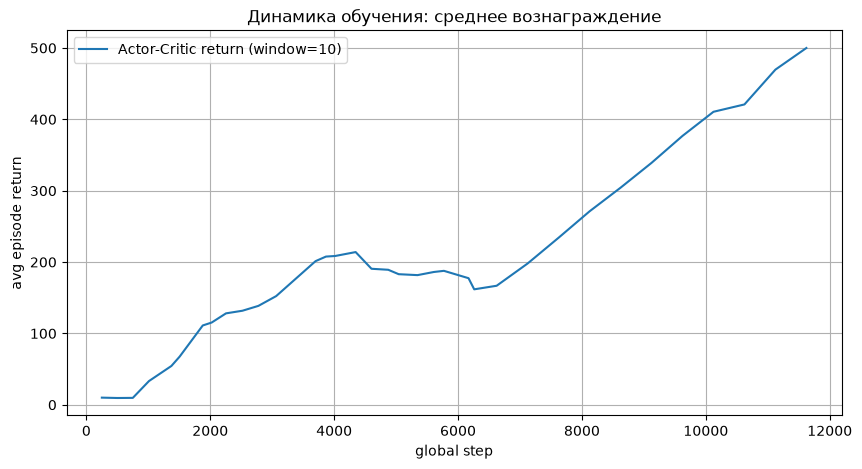

global_step=11623 | avg_return=500.000
Решено!


In [32]:
class ActorBatch:
    def __init__(self):
        self.logprobs = []
        self.q_values = []
        
    def append(self, log_prob, q_value):
        self.logprobs.append(log_prob)
        self.q_values.append(q_value)
    
    def clear(self):
        self.logprobs.clear()
        self.q_values.clear()

    
class ActorCriticModel(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()

        # Инициализируйте сеть агента с двумя головами: softmax-актора и линейного критика
        # self.net, self.actor_head, self.critic_head =
        """<codehere>"""
        def create_body():
            from_dim = input_dim
            layers = []
            for to_dim in hidden_dims:
                layers.extend([
                    nn.Linear(from_dim, to_dim),
                    nn.Tanh()
                ])
                from_dim = to_dim
            return layers
        

        self.net = None # Нет общего тела

        # Сеть актора (policy network)
        self.actor_head = nn.Sequential(
            *create_body(),
            nn.Linear(hidden_dims[-1], output_dim),
            nn.Softmax(dim=-1),
        )

        # Сеть критика (value network)
        self.critic_head = nn.Sequential(
            *create_body(),
            nn.Linear(hidden_dims[-1], output_dim),
        )
        """</codehere>"""
        
    def forward(self, state):
        # Вычислите выбранное действие, логарифм вероятности его выбора и соответствующее значение Q-функции
        """<codehere>"""
        if self.net is not None:
            state = self.net(state)
        
        # Получаем вероятности действий от актора
        action_probs = self.actor_head(state)

        # Создаем категориальное распределение
        dist = Categorical(action_probs)

        # Выбираем случайное действие согласно распределению
        action = dist.sample()
        
        # Вычисляем логарифм вероятности выбранного действия
        log_prob = dist.log_prob(action)
        action = action.item()
        
        # Вычисляем Q-значения без градиентов
        with torch.no_grad():
            Q_s = self.critic_head(state)
            Q_s_a = Q_s[action] # Q-значение для выбранного действия

            # NB: Или можно было бы возвращать для градиента стратегии не Q, а A — преимущество
            V_s, _ = torch.max(Q_s, axis=-1) # Максимальное Q-значение как оценка V(s)
            advantage = Q_s_a - V_s # Насколько выбранное действие лучше среднего
            Q_s_a = advantage # Используем преимущество вместо Q-значения
        """</codehere>"""
        
        return action, log_prob, Q_s_a
    
    def evaluate(self, state):
        # Вычислите значения Q-функции для данного состояния
        """<codehere>"""
        if self.net is not None:
            state = self.net(state)
        
        q_values = self.critic_head(state)
        """</codehere>"""
        return q_values


class ActorCriticAgent:
    def __init__(self, state_dim, action_dim, hidden_dims, lr, gamma, critic_rb_size):
        self.lr = lr
        self.gamma = gamma

        # Инициализируйте модель актор-критика и SGD оптимизатор (например, `torch.optim.Adam)`)
        """<codehere>"""
        self.actor_critic = ActorCriticModel(state_dim, hidden_dims, action_dim)
        
        # self.actor_opt = self.critic_opt = self.opt = torch.optim.Adam(self.actor_critic.parameters(), lr=lr)
        # NB: Можно использовать один оптимизатор на всех ^^^^, но по-хорошему имеет смысл
        # сделать каждому свой со своей скоростью обучения.
        self.actor_opt = torch.optim.Adam(self.actor_critic.actor_head.parameters(), lr=lr)
        self.critic_opt = torch.optim.Adam(self.actor_critic.critic_head.parameters(), lr=lr/2)
        """</codehere>"""

        self.actor_batch = ActorBatch()
        self.critic_rb = deque(maxlen=critic_rb_size)
        
    def act(self, state):
        # Произведите выбор действия и сохраните необходимые данные в батч для последующего обучения
        # Не забудьте сделать q_value.detach()
        # self.actor_batch.append(..)
        """<codehere>"""
        action, logprob, q_value = self.actor_critic(to_tensor(state))
        self.actor_batch.append(logprob, q_value.detach())

        # NB: Для дебага, можно сначала обучать только критика и убедиться, что DQN работает
        # action = select_action_eps_greedy(self.actor_critic.critic_head, state, 0.05)
        """</codehere>"""
        
        return action
        
    def append_to_replay_buffer(self, s, a, r, next_s, terminated):
        # Добавьте новый экземпляр данных в память прецедентов.
        """<codehere>"""
        self.critic_rb.append((s, a, r, next_s, terminated))
        """</codehere>"""
    
    def evaluate(self, state):
        return self.actor_critic.evaluate(state)
    
    def update(self, rollout_size, critic_batch_size, critic_updates_per_actor):
        if len(self.actor_batch.q_values) < rollout_size:
            return

        # Сначала обновляем критика несколько раз
        self.update_critic(critic_batch_size, critic_updates_per_actor)

        # Затем обновляем актора
        self.update_actor()

    def update_actor(self):
        # Получаем сохраненные данные
        Q_s_a = to_tensor(self.actor_batch.q_values)
        logprobs = torch.stack(self.actor_batch.logprobs)

        # Реализуйте шаг обновления актора — вычислите ошибку `loss` и произведите шаг обновления градиентным спуском. 
        """<codehere>"""
        # Считаем ошибку
        loss = -torch.mean(Q_s_a * logprobs)
        
        # Обновляем веса актора
        self.actor_opt.zero_grad()
        loss.backward()
        self.actor_opt.step()
        self.actor_batch.clear()
        """</codehere>"""
    
    def update_critic(self, batch_size, n_updates=1):
        # Реализуйте n_updates шагов обучения критика.
        """<codehere>"""

        if len(self.critic_rb) < batch_size:
            return

        # Ограничиваем число обновлений доступными данными
        if len(self.critic_rb) < batch_size * n_updates:
            n_updates = len(self.critic_rb) // batch_size

        # Делаем несколько обновлений
        for _ in range(n_updates):
            train_batch = sample_batch(self.critic_rb, batch_size)
            states, actions, rewards, next_states, terminateds = train_batch
            
            # Обновляем веса критика
            self.critic_opt.zero_grad()
            loss = self.compute_td_loss(states, actions, rewards, next_states, terminateds)
            loss.backward()
            self.critic_opt.step()
        """</codehere>"""
        
    def compute_td_loss(
        self, states, actions, rewards, next_states, terminateds, regularizer=0.1
    ):
        # переводим входные данные в тензоры
        s = to_tensor(states)                     # shape: [batch_size, state_size]
        a = to_tensor(actions, int).long()        # shape: [batch_size]
        r = to_tensor(rewards)                    # shape: [batch_size]
        s_next = to_tensor(next_states)           # shape: [batch_size, state_size]
        term = to_tensor(terminateds, bool)       # shape: [batch_size]

        
        # получаем Q[s, a] для выбранных действий в текущих состояниях (для каждого примера из батча)
        # Q_s_a = ...
        """<codehere>"""
        Q_s_a = torch.gather(
            self.evaluate(s), dim=1, index=torch.unsqueeze(a, 1)
        ).squeeze(1)
        """</codehere>"""
    
        # получаем Q[s_next, *] — значения полезности всех действий в следующих состояниях
        # Q_sn = ...,
        # а затем вычисляем V*[s_next] — оптимальные значения полезности следующих состояний
        # V_sn = ...
        """<codehere>"""
        with torch.no_grad():
            Q_sn = self.evaluate(s_next)
            V_sn, _ = torch.max(Q_sn, axis=-1)
        """</codehere>"""
    
        # вычисляем TD target и далее TD error
        # target = ...
        # td_error = ...
        """<codehere>"""
        target = r + self.gamma * V_sn * torch.logical_not(term)
        td_error = target - Q_s_a
        """</codehere>"""
    
        # MSE loss для минимизации
        loss = torch.mean(td_error ** 2)
        # добавляем регуляризацию на значения Q 
        loss += regularizer * Q_s_a.mean()
        return loss

def run_actor_critic(
        env_name="CartPole-v1", 
        hidden_dims=(128, 128), lr=5e-4,
        total_max_steps=500_000,
        train_schedule=1, replay_buffer_size=500, batch_size=64, critic_updates_per_actor=4,
        eval_schedule=1000, smooth_ret_window=10, success_ret=500.
):
    env = gym.make(env_name)
    episode_return_history = deque(maxlen=smooth_ret_window)
    all_steps = []
    all_returns = []
    fig, ax = plt.subplots(figsize=(10, 5))

    agent = ActorCriticAgent(
        state_dim=env.observation_space.shape[0], action_dim=env.action_space.n, hidden_dims=hidden_dims,
        lr=lr, gamma=.995, critic_rb_size=replay_buffer_size
    )
    
    s, _ = env.reset()
    done, episode_return = False, 0.
    eval = False

    for global_step in range(1, total_max_steps+1):
        a = agent.act(s)
        s_next, r, terminated, truncated, _ = env.step(a)
        episode_return += r
        done = terminated or truncated

        # train step
        agent.append_to_replay_buffer(s, a, r, s_next, terminated)
        agent.update(train_schedule, batch_size, critic_updates_per_actor)

        # evaluate
        if global_step % eval_schedule == 0:
            eval = True

        s = s_next
        if done:
            if eval:
                episode_return_history.append(episode_return)
                avg_return = np.mean(episode_return_history)
                all_steps.append(global_step)
                all_returns.append(avg_return)
                clear_output(wait=True)
                ax.clear()
                ax.plot(all_steps, all_returns, label=f'Actor-Critic return (window={smooth_ret_window})')
                ax.set_xlabel('global step')
                ax.set_ylabel('avg episode return')
                ax.set_title('Динамика обучения: среднее вознаграждение')
                ax.grid(True)
                ax.legend()
                display(fig)
                print(f'{global_step=} | {avg_return=:.3f}')
                if avg_return >= success_ret:
                    print('Решено!')
                    break

            s, _ = env.reset()
            done, episode_return = False, 0.
            eval = False
    plt.close(fig)

run_actor_critic(eval_schedule=250, total_max_steps=200_000)